<a href="https://colab.research.google.com/github/Maneshna/AI_LAB/blob/main/AILAB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Algorithm                Nodes Explored  Path Length  Path Cost
─────────────────────────────────────────────────────────────────
A* Manhattan (no diagonal)               64           22      22.00
A* Euclidean (diagonal)               47           15      17.90
BFS                                  98           22      22.00
UCS                                  98           22      22.00


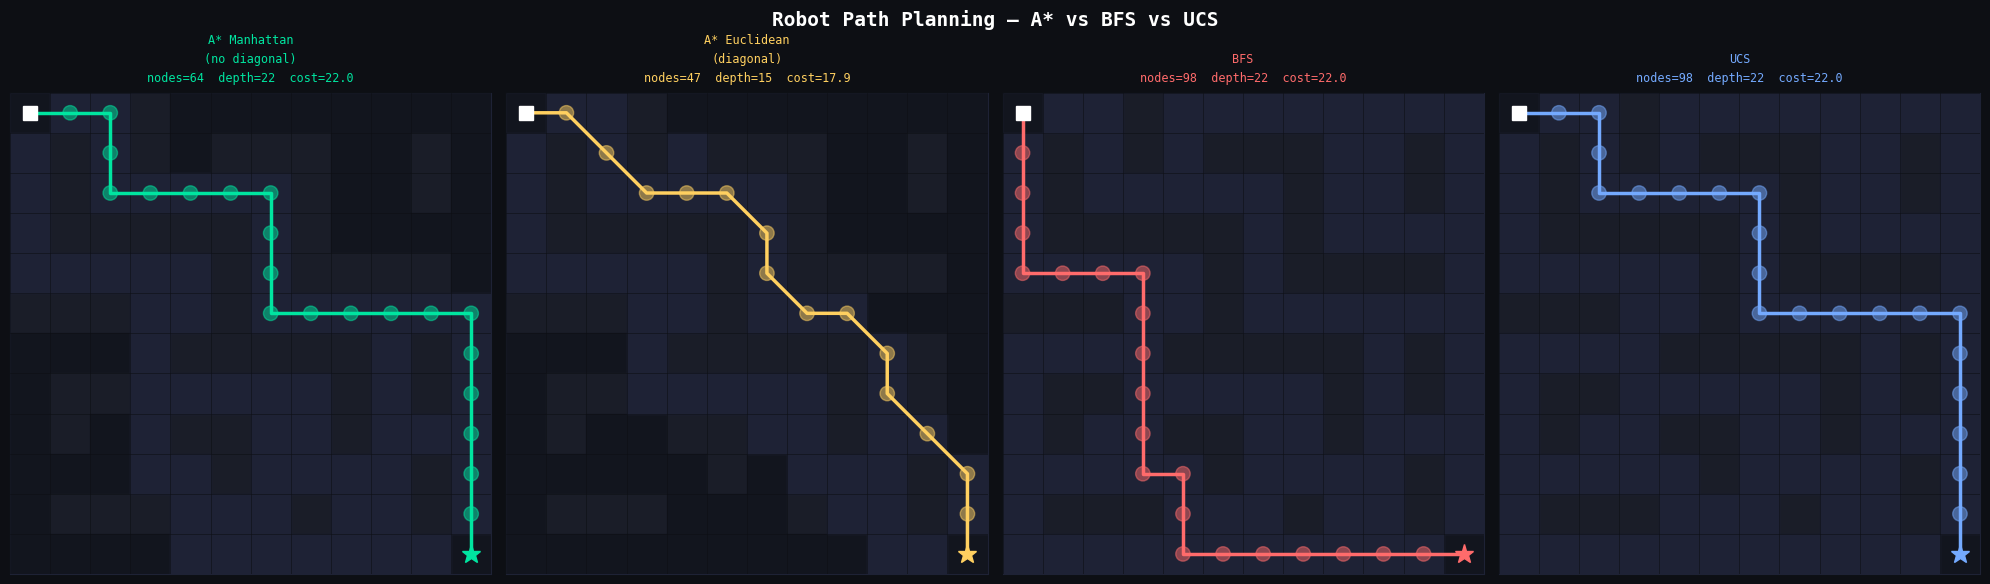


Saved → robot_path.png


In [ ]:
import heapq, math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from collections import deque

# ── Grid Setup ───────────────────────────────────────────────
GRID = [
    [0,0,0,1,0,0,0,0,0,0,0,0],
    [0,1,0,1,0,1,1,1,0,0,1,0],
    [0,1,0,0,0,0,0,1,0,0,1,0],
    [0,1,1,1,1,1,0,1,0,0,0,0],
    [0,0,0,0,0,1,0,1,1,1,1,0],
    [1,1,1,0,0,1,0,0,0,0,0,0],
    [0,0,0,0,1,1,1,1,1,0,1,0],
    [0,1,1,0,0,0,0,0,1,0,1,0],
    [0,1,0,0,1,1,0,0,1,0,0,0],
    [0,0,0,0,0,1,0,0,0,0,1,0],
    [0,1,1,1,0,0,0,1,0,0,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0],
]
ROWS, COLS = len(GRID), len(GRID[0])
START, GOAL = (0, 0), (11, 11)

CARDINAL = [(-1,0),(1,0),(0,-1),(0,1)]
DIAGONAL = CARDINAL + [(-1,-1),(-1,1),(1,-1),(1,1)]

def valid(r, c):
    return 0 <= r < ROWS and 0 <= c < COLS and GRID[r][c] == 0

# ── Heuristics ───────────────────────────────────────────────
def manhattan(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def euclidean(a, b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

# ── Path Reconstruction ──────────────────────────────────────
def reconstruct(came_from, node):
    path = []
    while node is not None:
        path.append(node)
        node = came_from[node]
    return path[::-1]

# ── A* Search ────────────────────────────────────────────────
def astar(start, goal, heuristic, diagonal=False):
    dirs = DIAGONAL if diagonal else CARDINAL
    heap = [(heuristic(start, goal), 0, start)]
    came_from = {start: None}
    g_cost = {start: 0}
    explored = []

    while heap:
        _, g, cur = heapq.heappop(heap)
        explored.append(cur)
        if cur == goal:
            return reconstruct(came_from, cur), explored

        for dr, dc in dirs:
            nb = (cur[0]+dr, cur[1]+dc)
            if not valid(*nb): continue
            step = math.sqrt(dr**2 + dc**2)
            new_g = g_cost[cur] + step
            if nb not in g_cost or new_g < g_cost[nb]:
                g_cost[nb] = new_g
                came_from[nb] = cur
                heapq.heappush(heap, (new_g + heuristic(nb, goal), new_g, nb))

    return [], explored

# ── BFS ──────────────────────────────────────────────────────
def bfs(start, goal):
    queue = deque([start])
    came_from = {start: None}
    explored = []

    while queue:
        cur = queue.popleft()
        explored.append(cur)
        if cur == goal:
            return reconstruct(came_from, cur), explored
        for dr, dc in CARDINAL:
            nb = (cur[0]+dr, cur[1]+dc)
            if valid(*nb) and nb not in came_from:
                came_from[nb] = cur
                queue.append(nb)

    return [], explored

# ── UCS ──────────────────────────────────────────────────────
def ucs(start, goal):
    heap = [(0, start)]
    came_from = {start: None}
    cost = {start: 0}
    explored = []

    while heap:
        c, cur = heapq.heappop(heap)
        explored.append(cur)
        if cur == goal:
            return reconstruct(came_from, cur), explored
        for dr, dc in CARDINAL:
            nb = (cur[0]+dr, cur[1]+dc)
            if not valid(*nb): continue
            nc = c + 1
            if nb not in cost or nc < cost[nb]:
                cost[nb] = nc
                came_from[nb] = cur
                heapq.heappush(heap, (nc, nb))

    return [], explored

# ── Run All Algorithms ───────────────────────────────────────
results = {
    "A* Manhattan\n(no diagonal)" : astar(START, GOAL, manhattan, diagonal=False),
    "A* Euclidean\n(diagonal)"    : astar(START, GOAL, euclidean, diagonal=True),
    "BFS"                          : bfs(START, GOAL),
    "UCS"                          : ucs(START, GOAL),
}

# ── Print Stats ──────────────────────────────────────────────
print(f"\n{'Algorithm':<22} {'Nodes Explored':>16} {'Path Length':>12} {'Path Cost':>10}")
print("─" * 65)
for name, (path, explored) in results.items():
    label = name.replace('\n', ' ')
    cost = sum(
        math.sqrt((path[i][0]-path[i-1][0])**2 + (path[i][1]-path[i-1][1])**2)
        for i in range(1, len(path))
    ) if path else float('inf')
    print(f"{label:<22} {len(explored):>16} {len(path)-1:>12} {cost:>10.2f}")

# ── Visualization ────────────────────────────────────────────
PALETTE = {
    "A* Manhattan\n(no diagonal)": "#00e5a0",
    "A* Euclidean\n(diagonal)"   : "#ffd060",
    "BFS"                         : "#ff6b6b",
    "UCS"                         : "#74aaff",
}

BG      = "#0d0f14"
WALL    = "#1a1d28"
FREE    = "#12151e"
EXPCLR  = "#1e2235"

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("Robot Path Planning — A* vs BFS vs UCS",
             color="white", fontsize=14, fontweight="bold", y=1.01,
             fontfamily="monospace")

for ax, (name, (path, explored)) in zip(axes, results.items()):
    ax.set_facecolor(BG)
    ax.set_xlim(-0.5, COLS-0.5)
    ax.set_ylim(ROWS-0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("#1e2235")

    # Draw free cells
    for r in range(ROWS):
        for c in range(COLS):
            color = WALL if GRID[r][c] == 1 else FREE
            ax.add_patch(patches.Rectangle((c-.5, r-.5), 1, 1,
                         color=color, zorder=1))

    # Draw explored cells
    exp_set = set(explored)
    for (r, c) in exp_set:
        if (r,c) not in (START, GOAL):
            ax.add_patch(patches.Rectangle((c-.5, r-.5), 1, 1,
                         color=EXPCLR, zorder=2))

    # Draw grid lines
    for r in range(ROWS+1):
        ax.axhline(r-.5, color="#0d0f14", linewidth=0.4, zorder=3)
    for c in range(COLS+1):
        ax.axvline(c-.5, color="#0d0f14", linewidth=0.4, zorder=3)

    # Draw path
    color = PALETTE[name]
    if path:
        pr = [p[0] for p in path]
        pc = [p[1] for p in path]
        ax.plot(pc, pr, color=color, linewidth=2.5, zorder=4, solid_capstyle='round')
        for (r, c) in path[1:-1]:
            ax.add_patch(patches.Circle((c, r), 0.18, color=color, alpha=0.5, zorder=5))

    # Start & Goal markers
    ax.plot(START[1], START[0], 's', color='white',   markersize=10, zorder=6)
    ax.plot(GOAL[1],  GOAL[0],  '*', color=color,     markersize=14, zorder=6)

    label = name.replace('\n', ' ')
    cost_val = sum(
        math.sqrt((path[i][0]-path[i-1][0])**2 + (path[i][1]-path[i-1][1])**2)
        for i in range(1, len(path))
    ) if path else 0

    ax.set_title(
        f"{name}\nnodes={len(explored)}  depth={len(path)-1}  cost={cost_val:.1f}",
        color=color, fontsize=8.5, pad=8, fontfamily="monospace",
        linespacing=1.6
    )

plt.tight_layout()
plt.savefig("robot_path.png", dpi=160, bbox_inches='tight', facecolor=BG)
plt.show()
print("\nSaved → robot_path.png")